Step 1 — Structural sanity checks
- Shape of RNA matrix
- Shape of phenotype
- Shape of survival
- Confirm orientation (genes × samples vs samples × genes)

Step 2 — ID alignment
- Extract patient IDs from RNA sample IDs
- Count intersection size
- Print number retained after merge
- Do not proceed until this is airtight.
    
Step 3 — Survival inspection
- Distribution of survival time,
- Event rate (how many deaths?)
- How many ≥ 5 years?
- If event rate is tiny, modeling will be unstable.
    
Step 4 — RNA basics
- Gene count
- Remove low-expression genes
- Check for obvious outlier samples

In [1]:
import pandas as pd

In [2]:
# Load data

RAW_DIR = "../data/raw"

rna_path = f"{RAW_DIR}/TCGA-BRCA.star_counts.tsv.gz"
clin_path = f"{RAW_DIR}/TCGA-BRCA.clinical.tsv.gz"
surv_path = f"{RAW_DIR}/TCGA-BRCA.survival.tsv.gz"

# Load
rna_raw_df = pd.read_csv(rna_path, sep="\t")
clin_raw_df = pd.read_csv(clin_path, sep="\t")
surv_raw_df = pd.read_csv(surv_path, sep="\t")

## EDA

### Structural sanity checks

In [3]:
# Check

# Shapes
print("RNA shape:", rna_raw_df.shape)
print("Clinical shape:", clin_raw_df.shape)
print("Survival shape:", surv_raw_df.shape)

# Peek at columns / headers
print("\nRNA head, tail:")
display(rna_raw_df.head())
display(rna_raw_df.tail())

print("\nClinical head, tail:")
display(clin_raw_df.head())
display(clin_raw_df.tail())

print("\nSurvival head, tail:")
display(surv_raw_df.head())
display(surv_raw_df.tail())

RNA shape: (60660, 1227)
Clinical shape: (1255, 85)
Survival shape: (1232, 4)

RNA head, tail:


,Ensembl_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B,TCGA-AC-A62V-01A,TCGA-AO-A0J5-01A,TCGA-BH-A0B1-01A,TCGA-A2-A0YM-01A,...,TCGA-E2-A1IG-01A,TCGA-E9-A1NA-01A,TCGA-D8-A1JP-01A,TCGA-AR-A252-01A,TCGA-D8-A1XL-01A,TCGA-BH-A0EI-01A,TCGA-E2-A1IO-01A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-A1-A0SN-01A
0,ENSG00000000003.15,11.737670,9.781360,13.122504,11.016808,11.000000,9.614710,11.092096,12.103616,12.417325,...,10.747354,10.360847,10.675957,11.337064,11.697836,12.339850,12.131857,8.974415,13.326289,9.710806
1,ENSG00000000005.6,7.721099,3.321928,0.000000,6.686501,3.807355,4.087463,5.392317,3.000000,3.321928,...,1.584963,2.000000,1.000000,8.164907,0.000000,2.807355,3.906891,3.700440,3.807355,1.000000
2,ENSG00000000419.13,11.042343,11.357552,11.506308,10.801708,11.074141,11.107217,10.318543,11.160502,11.072803,...,10.429407,10.811375,10.835261,10.693487,11.922213,11.221587,10.913637,11.659550,10.962173,12.416270
3,ENSG00000000457.14,11.036860,10.754888,12.218260,11.190442,10.857981,8.539159,11.527966,10.635718,9.945444,...,10.366322,10.558421,11.262682,10.751544,10.607330,10.163650,10.575539,11.929258,11.403012,10.870365
4,ENSG00000000460.17,9.131857,8.721099,10.973697,10.761551,9.550747,8.550747,9.177420,9.727920,10.504819,...,8.661778,9.000000,9.794416,9.231221,9.782998,9.252665,8.632995,10.562242,10.060696,9.722808


,Ensembl_ID,TCGA-D8-A146-01A,TCGA-AQ-A0Y5-01A,TCGA-C8-A274-01A,TCGA-BH-A0BD-01A,TCGA-B6-A1KC-01B,TCGA-AC-A62V-01A,TCGA-AO-A0J5-01A,TCGA-BH-A0B1-01A,TCGA-A2-A0YM-01A,...,TCGA-E2-A1IG-01A,TCGA-E9-A1NA-01A,TCGA-D8-A1JP-01A,TCGA-AR-A252-01A,TCGA-D8-A1XL-01A,TCGA-BH-A0EI-01A,TCGA-E2-A1IO-01A,TCGA-E2-A15R-01A,TCGA-B6-A0IP-01A,TCGA-A1-A0SN-01A
60655,ENSG00000288669.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
60656,ENSG00000288670.1,8.184875,9.584963,9.942515,9.590587,10.625709,7.851749,8.515700,9.100662,9.005625,...,9.372865,7.754888,8.836050,8.243174,8.741467,8.519636,8.049849,10.486835,9.603626,8.252665
60657,ENSG00000288671.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
60658,ENSG00000288674.1,2.807355,2.807355,3.906891,3.000000,2.321928,3.169925,3.000000,2.584963,2.807355,...,2.000000,3.000000,2.000000,3.000000,2.000000,2.321928,3.000000,2.321928,4.169925,3.169925
60659,ENSG00000288675.1,4.954196,5.247928,4.321928,3.807355,3.807355,5.209453,5.209453,3.321928,4.169925,...,4.584963,4.857981,3.584963,4.954196,5.672425,5.209453,4.321928,6.285402,4.459432,4.000000



Clinical head, tail:


,sample,id,disease_type,case_id,submitter_id,primary_site,alcohol_history.exposures,race.demographic,gender.demographic,ethnicity.demographic,...,days_to_collection.samples,initial_weight.samples,preservation_method.samples,pathology_report_uuid.samples,oct_embedded.samples,specimen_type.samples,days_to_sample_procurement.samples,is_ffpe.samples,tissue_type.samples,annotations.samples
0,TCGA-BH-A0W3-01A,3c612e12-6de8-44fa-a095-805c45474821,Ductal and Lobular Neoplasms,3c612e12-6de8-44fa-a095-805c45474821,TCGA-BH-A0W3,Breast,Not Reported,white,female,not hispanic or latino,...,85.0,120.0,OCT,801A4E2F-E26E-424F-BF42-CD0D9CD62BCE,True,Solid Tissue,NaN,False,Tumor,NaN
1,TCGA-AR-A24V-01A,3cb06c7a-f2a8-448b-91a8-dd201bbf2ddd,Ductal and Lobular Neoplasms,3cb06c7a-f2a8-448b-91a8-dd201bbf2ddd,TCGA-AR-A24V,Breast,Not Reported,white,female,not hispanic or latino,...,1720.0,400.0,OCT,468CD293-C9F7-43C6-A40A-18FCDD22F6AA,True,Solid Tissue,NaN,False,Tumor,NaN
2,TCGA-E9-A1NE-01A,3d676bba-154b-4d22-ab59-d4d4da051b94,Ductal and Lobular Neoplasms,3d676bba-154b-4d22-ab59-d4d4da051b94,TCGA-E9-A1NE,Breast,Not Reported,white,female,not hispanic or latino,...,31.0,280.0,OCT,CF6E29A2-FAE6-45BB-B625-33877887A89E,True,Solid Tissue,NaN,False,Tumor,NaN
3,TCGA-E9-A1NE-11A,3d676bba-154b-4d22-ab59-d4d4da051b94,Ductal and Lobular Neoplasms,3d676bba-154b-4d22-ab59-d4d4da051b94,TCGA-E9-A1NE,Breast,Not Reported,white,female,not hispanic or latino,...,31.0,830.0,OCT,NaN,True,Solid Tissue,NaN,False,Normal,NaN
4,TCGA-AC-A8OQ-01A,dfaabd03-2d40-4422-b210-caf112ff4229,Ductal and Lobular Neoplasms,dfaabd03-2d40-4422-b210-caf112ff4229,TCGA-AC-A8OQ,Breast,Not Reported,black or african american,female,not hispanic or latino,...,742.0,100.0,Unknown,FFA6F9F3-71C1-4AF9-B9F7-0466550EBC90,False,Solid Tissue,NaN,False,Tumor,NaN


,sample,id,disease_type,case_id,submitter_id,primary_site,alcohol_history.exposures,race.demographic,gender.demographic,ethnicity.demographic,...,days_to_collection.samples,initial_weight.samples,preservation_method.samples,pathology_report_uuid.samples,oct_embedded.samples,specimen_type.samples,days_to_sample_procurement.samples,is_ffpe.samples,tissue_type.samples,annotations.samples
1250,TCGA-BH-A1FH-11B,1783cac1-253a-40af-a9ac-48dfb20e1ab8,Ductal and Lobular Neoplasms,1783cac1-253a-40af-a9ac-48dfb20e1ab8,TCGA-BH-A1FH,Breast,Not Reported,white,female,not hispanic or latino,...,4670.0,280.0,Unknown,NaN,False,Solid Tissue,NaN,False,Normal,NaN
1251,TCGA-BH-A1FH-01A,1783cac1-253a-40af-a9ac-48dfb20e1ab8,Ductal and Lobular Neoplasms,1783cac1-253a-40af-a9ac-48dfb20e1ab8,TCGA-BH-A1FH,Breast,Not Reported,white,female,not hispanic or latino,...,4670.0,430.0,OCT,501C3E1B-573B-4A5A-A0ED-3CD15432E6FF,True,Solid Tissue,NaN,False,Tumor,NaN
1252,TCGA-AR-A1AO-01A,623befd6-0ca4-4a6c-9cf5-d9385c3b718f,Ductal and Lobular Neoplasms,623befd6-0ca4-4a6c-9cf5-d9385c3b718f,TCGA-AR-A1AO,Breast,Not Reported,white,female,not hispanic or latino,...,1471.0,200.0,OCT,37EF1828-0A53-4358-97C7-A7849EC653AF,True,Solid Tissue,NaN,False,Tumor,NaN
1253,TCGA-A7-A0D9-01A,17baef7c-d97d-4b98-ab53-503ef856523d,Ductal and Lobular Neoplasms,17baef7c-d97d-4b98-ab53-503ef856523d,TCGA-A7-A0D9,Breast,Not Reported,white,female,not hispanic or latino,...,173.0,1760.0,Unknown,7D5763F7-7284-4AF5-BBFC-5D8B5CB7F495,False,Solid Tissue,NaN,False,Tumor,NaN
1254,TCGA-A7-A0D9-11A,17baef7c-d97d-4b98-ab53-503ef856523d,Ductal and Lobular Neoplasms,17baef7c-d97d-4b98-ab53-503ef856523d,TCGA-A7-A0D9,Breast,Not Reported,white,female,not hispanic or latino,...,173.0,1830.0,Unknown,NaN,False,Solid Tissue,NaN,False,Normal,NaN



Survival head, tail:


,sample,OS.time,OS,_PATIENT
0,TCGA-C8-A275-01A,1.0,0,TCGA-C8-A275
1,TCGA-AC-A7VC-01A,1.0,0,TCGA-AC-A7VC
2,TCGA-BH-A1F8-01A,1.0,1,TCGA-BH-A1F8
3,TCGA-BH-A1F8-11B,1.0,1,TCGA-BH-A1F8
4,TCGA-PL-A8LX-01A,5.0,0,TCGA-PL-A8LX


,sample,OS.time,OS,_PATIENT
1227,TCGA-B6-A0RE-01A,7777.0,0,TCGA-B6-A0RE
1228,TCGA-B6-A0RN-01A,8008.0,0,TCGA-B6-A0RN
1229,TCGA-B6-A0IA-01A,8391.0,0,TCGA-B6-A0IA
1230,TCGA-B6-A0I5-01A,8556.0,0,TCGA-B6-A0I5
1231,TCGA-B6-A0RU-01A,8605.0,0,TCGA-B6-A0RU


In [4]:
clin_raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 85 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   sample                                                     1255 non-null   object 
 1   id                                                         1255 non-null   object 
 2   disease_type                                               1255 non-null   object 
 3   case_id                                                    1255 non-null   object 
 4   submitter_id                                               1255 non-null   object 
 5   primary_site                                               1255 non-null   object 
 6   alcohol_history.exposures                                  1254 non-null   object 
 7   race.demographic                                           1254 non-null   object 
 8   gender.d

In [5]:
clin_raw_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age_at_index.demographic,1254.0,58.198565,13.360242,26.000000,48.000000,58.000000,67.000000,90.000000
days_to_birth.demographic,1238.0,-21489.376414,4864.993235,-32872.000000,-24791.000000,-21472.000000,-17786.000000,-9706.000000
year_of_birth.demographic,1251.0,1949.451639,13.868405,1902.000000,1940.000000,1950.000000,1960.000000,1984.000000
year_of_death.demographic,147.0,2004.333333,4.046533,1992.000000,2001.000000,2005.000000,2008.000000,2013.000000
days_to_death.demographic,203.0,1586.270936,1237.292209,0.000000,658.500000,1275.000000,2273.000000,7455.000000
days_to_diagnosis.diagnoses,1254.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
days_to_last_follow_up.diagnoses,1107.0,1184.824752,1145.193000,-7.000000,441.000000,788.000000,1607.500000,8605.000000
age_at_diagnosis.diagnoses,1238.0,21489.376414,4864.993235,9706.000000,17786.000000,21472.000000,24791.000000,32872.000000
year_of_diagnosis.diagnoses,1252.0,2007.653355,4.396019,1988.000000,2006.000000,2009.000000,2010.000000,2013.000000
age_at_earliest_diagnosis.diagnoses.xena_derived,1238.0,21489.376414,4864.993235,9706.000000,17786.000000,21472.000000,24791.000000,32872.000000


In [6]:
surv_raw_df.describe().T

,count,mean,std,min,25%,50%,75%,max
OS.time,1232.0,1273.177760,1154.554180,1.0,486.5,922.0,1734.5,8605.0
OS,1232.0,0.163149,0.369652,0.0,0.0,0.0,0.0,1.0


In [7]:
with pd.option_context("display.max_rows", None):
    display(clin_raw_df.head().T)

,0,1,2,3,4
sample,TCGA-BH-A0W3-01A,TCGA-AR-A24V-01A,TCGA-E9-A1NE-01A,TCGA-E9-A1NE-11A,TCGA-AC-A8OQ-01A
id,3c612e12-6de8-44fa-a095-805c45474821,3cb06c7a-f2a8-448b-91a8-dd201bbf2ddd,3d676bba-154b-4d22-ab59-d4d4da051b94,3d676bba-154b-4d22-ab59-d4d4da051b94,dfaabd03-2d40-4422-b210-caf112ff4229
disease_type,Ductal and Lobular Neoplasms,Ductal and Lobular Neoplasms,Ductal and Lobular Neoplasms,Ductal and Lobular Neoplasms,Ductal and Lobular Neoplasms
case_id,3c612e12-6de8-44fa-a095-805c45474821,3cb06c7a-f2a8-448b-91a8-dd201bbf2ddd,3d676bba-154b-4d22-ab59-d4d4da051b94,3d676bba-154b-4d22-ab59-d4d4da051b94,dfaabd03-2d40-4422-b210-caf112ff4229
submitter_id,TCGA-BH-A0W3,TCGA-AR-A24V,TCGA-E9-A1NE,TCGA-E9-A1NE,TCGA-AC-A8OQ
primary_site,Breast,Breast,Breast,Breast,Breast
alcohol_history.exposures,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported
race.demographic,white,white,white,white,black or african american
gender.demographic,female,female,female,female,female
ethnicity.demographic,not hispanic or latino,not hispanic or latino,not hispanic or latino,not hispanic or latino,not hispanic or latino


### ID alignment
#### Check sample ID intersections between the 3 datasets

In [8]:
# Extract ID sets
clin_ids = set(clin_raw_df["sample"])
surv_ids = set(surv_raw_df["sample"])

# RNA sample IDs are column names (exclude first gene column if needed)
rna_cols = rna_raw_df.columns.tolist()

# If first column is gene identifier, drop it
if not rna_cols[0].startswith("TCGA-"):
    rna_ids = set(rna_cols[1:])
else:
    rna_ids = set(rna_cols)

print("Clinical N:", len(clin_ids))
print("Survival N:", len(surv_ids))
print("RNA N:", len(rna_ids))

print("\nClinical ∩ Survival:", len(clin_ids & surv_ids))
print("Clinical ∩ RNA:", len(clin_ids & rna_ids))
print("Survival ∩ RNA:", len(surv_ids & rna_ids))
print("All three intersect:", len(clin_ids & surv_ids & rna_ids))

Clinical N: 1255
Survival N: 1232
RNA N: 1226

Clinical ∩ Survival: 1232
Clinical ∩ RNA: 1226
Survival ∩ RNA: 1203
All three intersect: 1203


### Handle multiple samples per patient

In [9]:
# How many samples per patient?
surv_raw_df["_PATIENT"].value_counts().describe()

count    1076.000000
mean        1.144981
std         0.372775
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         3.000000
Name: count, dtype: float64

In [10]:
# Patients with >1 sample
dup_patients = surv_raw_df["_PATIENT"].value_counts()
dup_patients = dup_patients[dup_patients > 1]

print("Patients with multiple samples:", len(dup_patients))
dup_patients.head()

Patients with multiple samples: 148


_PATIENT
TCGA-A7-A13E    3
TCGA-A7-A13G    3
TCGA-A7-A0DC    3
TCGA-BH-A1ES    3
TCGA-E2-A15K    3
Name: count, dtype: int64

In [11]:
surv_raw_df[surv_raw_df.duplicated(subset="_PATIENT", keep=False)].sort_values("_PATIENT")

,sample,OS.time,OS,_PATIENT
706,TCGA-A7-A0CE-01A,1074.0,0,TCGA-A7-A0CE
705,TCGA-A7-A0CE-11A,1074.0,0,TCGA-A7-A0CE
708,TCGA-A7-A0CH-11A,1079.0,0,TCGA-A7-A0CH
707,TCGA-A7-A0CH-01A,1079.0,0,TCGA-A7-A0CH
735,TCGA-A7-A0D9-11A,1139.0,0,TCGA-A7-A0D9
...,...,...,...,...
95,TCGA-GI-A2C8-11A,225.0,0,TCGA-GI-A2C8
1172,TCGA-GI-A2C9-01A,3342.0,0,TCGA-GI-A2C9
1173,TCGA-GI-A2C9-11A,3342.0,0,TCGA-GI-A2C9
293,TCGA-XX-A899-11A,467.0,0,TCGA-XX-A899


In [12]:
# Check sample ID suffixes
suffixes = surv_raw_df["sample"].str.split("-").str[-1]

suffixes.value_counts()

sample
01A    1064
11A     121
01B      24
11B      15
06A       7
01C       1
Name: count, dtype: int64

In [13]:
# Filter sample IDs to 1 per patient ID

# In TCGA:
# 01A = primary tumor
# 11A/11B = normal tissue
# 06A = metastatic tumor
# So filter to primary tumor only:
surv_df = surv_raw_df[
    surv_raw_df["sample"].str.split("-").str[-1].str.startswith("01")
].copy()

surv_df["suffix"] = surv_df["sample"].str.split("-").str[-1]

# 01A, 01B, 01C are primary tumor vials
# Filter to one per patient
surv_df = (
    surv_df.sort_values("suffix")   # 01A < 01B < 01C
           .drop_duplicates(subset="_PATIENT", keep="first")
)

# Check
display(surv_df.head())
display(surv_df.tail())
print(surv_df["_PATIENT"].value_counts().max())
surv_df["_PATIENT"].value_counts().describe()

,sample,OS.time,OS,_PATIENT,suffix
0,TCGA-C8-A275-01A,1.0,0,TCGA-C8-A275,01A
784,TCGA-E9-A22G-01A,1239.0,0,TCGA-E9-A22G,01A
785,TCGA-E2-A14P-01A,1246.0,0,TCGA-E2-A14P,01A
786,TCGA-BH-A0H9-01A,1247.0,0,TCGA-BH-A0H9,01A
788,TCGA-E9-A22D-01A,1248.0,0,TCGA-E9-A22D,01A


,sample,OS.time,OS,_PATIENT,suffix
1109,TCGA-BH-A0C7-01B,2767.0,0,TCGA-BH-A0C7,01B
534,TCGA-AQ-A04H-01B,754.0,0,TCGA-AQ-A04H,01B
943,TCGA-AO-A03M-01B,1866.0,0,TCGA-AO-A03M,01B
1198,TCGA-AQ-A04L-01B,3957.0,0,TCGA-AQ-A04L,01B
930,TCGA-AO-A03U-01B,1793.0,1,TCGA-AO-A03U,01B


1


count    1076.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: count, dtype: float64

### Survival inspection

**5-year survival chosen**

**5-Year Overall Survival Definition**
- Primary endpoint: 5-year overall survival (≥ 1825 days)
- Event (label = 1): death within 5 years
- Survivor (label = 0): alive with ≥ 5 years of follow-up
- Excluded: alive with < 5 years of follow-up (censored before cutoff)

**Rationale**
- Minimizes label ambiguity from censoring
- Provides a clinically meaningful endpoint
- Maintains adequate event rate (~33%)
- Preserves sufficient cohort size (n ≈ 301) for stable modeling

In [14]:
# Basic survival summary

surv_df["OS.time"].describe()

count    1076.000000
mean     1256.117100
std      1190.442161
min         1.000000
25%       460.250000
50%       860.000000
75%      1688.000000
max      8605.000000
Name: OS.time, dtype: float64

In [17]:
# Event rate (how many deaths)

n_total = len(surv_df)
n_events = surv_df["OS"].sum()
event_rate = n_events / n_total

print("Total patients:", n_total)
print("Number of deaths:", int(n_events))
print("Event rate:", round(event_rate, 3))

Total patients: 1076
Number of deaths: 150
Event rate: 0.139


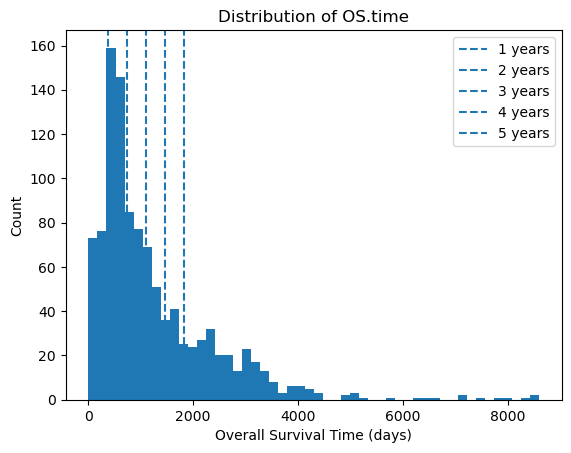

In [24]:
import matplotlib.pyplot as plt

plt.hist(surv_df["OS.time"], bins=50)

plt.axvline(365, linestyle="--", label="1 years")
plt.axvline(730, linestyle="--", label="2 years")
plt.axvline(1095, linestyle="--", label="3 years")
plt.axvline(1460, linestyle="--", label="4 years")
plt.axvline(1825, linestyle="--", label="5 years")

plt.legend()
plt.xlabel("Overall Survival Time (days)")
plt.ylabel("Count")
plt.title("Distribution of OS.time")
plt.show()

In [31]:
# How many ≥ 5 years (1825 days)

five_year_days = 1825

n_ge_5y = (surv_df["OS.time"] >= five_year_days).sum()
print("Patients with follow-up ≥ 5 years:", n_ge_5y)
print("Proportion:", round(n_ge_5y / n_total, 3))


# Check how many patients work for a 5 year survival cutoff

died_before_5y = ((surv_df["OS"] == 1) & (surv_df["OS.time"] < five_year_days)).sum()
alive_ge_5y = ((surv_df["OS"] == 0) & (surv_df["OS.time"] >= five_year_days)).sum()
alive_lt_5y = ((surv_df["OS"] == 0) & (surv_df["OS.time"] < five_year_days)).sum()

print("Died <5y:", died_before_5y)
print("Alive ≥5y:", alive_ge_5y)
print("Alive <5y (censored):", alive_lt_5y)

Patients with follow-up ≥ 5 years: 251
Proportion: 0.233
Died <5y: 100
Alive ≥5y: 201
Alive <5y (censored): 725


In [ ]:
# How many ≥ 3 years (1825 days)

three_year_days = 1095

n_ge_3y = (surv_df["OS.time"] >= three_year_days).sum()
print("Patients with follow-up ≥ 3 years:", n_ge_3y)
print("Proportion:", round(n_ge_3y / n_total, 3))


# Check how many patients work for a 5 year survival cutoff

died_before_3y = ((surv_df["OS"] == 1) & (surv_df["OS.time"] < three_year_days)).sum()
alive_ge_3y = ((surv_df["OS"] == 0) & (surv_df["OS.time"] >= three_year_days)).sum()
alive_lt_3y = ((surv_df["OS"] == 0) & (surv_df["OS.time"] < three_year_days)).sum()

print("Died <3y:", died_before_3y)
print("Alive ≥3y:", alive_ge_3y)
print("Alive <3y (censored):", alive_lt_3y)

In [39]:
# Filter to patients useable for 5 year survival end point

five_year_days = 1825

mask_use = (
    ((surv_df["OS"] == 1) & (surv_df["OS.time"] < five_year_days)) |
    ((surv_df["OS"] == 0) & (surv_df["OS.time"] >= five_year_days))
)

surv_df = surv_df.loc[mask_use].copy()

print("Filtered cohort size:", len(surv_df))

Filtered cohort size: 301


### RNA-seq EDA

In [38]:
cohort_cols = ["Ensembl_ID"] + rna_raw_df.columns.intersection(surv_df["sample"]).tolist()
rna_df = rna_raw_df.loc[:, cohort_cols]

print("RNA shape before:", rna_raw_df.shape)
print("RNA shape after filtering:", rna_df.shape)

RNA shape before: (60660, 1227)
RNA shape after filtering: (60660, 1072)


In [35]:
expr = rna_raw_df.iloc[:, 1:]  # samples as columns
sample_mean = expr.mean(axis=0).rename("sample_mean_expr")

# later, when you build clinical features:
# clinical_df = clinical_df.merge(sample_mean, left_on="sample", right_index=True, how="inner")

In [36]:
sample_mean

TCGA-D8-A146-01A    3.487233
TCGA-AQ-A0Y5-01A    3.287776
TCGA-C8-A274-01A    3.421348
TCGA-BH-A0BD-01A    3.415141
TCGA-B6-A1KC-01B    3.410399
                      ...   
TCGA-BH-A0EI-01A    3.278537
TCGA-E2-A1IO-01A    3.367066
TCGA-E2-A15R-01A    3.511448
TCGA-B6-A0IP-01A    3.526227
TCGA-A1-A0SN-01A    3.269386
Name: sample_mean_expr, Length: 1226, dtype: float64